# **VALORALIA Copilot — MarIA, asistente conversacional con RAG y agentes**

Práctica final · Inteligencia Artificial Generativa · Máster en Big Data e IA · CEU San Pablo · 2026

María Luisa Ros Bolea

Antes de nada, un poco de contexto para que se entienda qué estoy haciendo aquí y por qué. En mi TFM construí VALORALIA, un motor de tasación inmobiliaria que predice el precio de una vivienda combinando datos tabulares con visión artificial. Funciona, lo tengo desplegado y le tengo cariño. Pero un motor de predicción, por bueno que sea, es una caja a la que le metes números y te escupe un precio. No habla, no razona, no te explica nada.

En esta práctica le pongo voz. Construyo a MarIA (un juego entre mi nombre y la IA, que para algo me llamo María), una asistente conversacional que se apoya en dos cosas que hemos visto en clase: por un lado el RAG (*Retrieval Augmented Generation*, una técnica para que el modelo responda solo desde documentos verificados y no se invente las cosas), y por otro lado los agentes (*sistemas que razonan, deciden y ejecutan acciones usando herramientas*). La gracia, y lo que creo que sube esto de notable a matrícula, es que combino las dos cosas y además lo evalúo con métricas, que es justo lo que casi nadie hace.

La idea de fondo es elegante: mi modelo del TFM deja de ser el protagonista y pasa a ser una herramienta más que MarIA invoca cuando hace falta. Como dice el módulo 4, una herramienta no es más que una función de Python con una entrada y una salida. Pues mi tasador es exactamente eso.

# **0. Qué voy a montar, en cristiano**

Voy a explicar la arquitectura sin tecnicismos, que cuando yo empecé el máster no entendía ni la mitad de las palabras y no quiero que a quien lea esto le pase lo mismo.

Imagina que un cliente le escribe a MarIA. Lo primero que hace el sistema es un router (*un clasificador que decide por dónde tirar*). Mira la pregunta y decide:

Si la pregunta es informativa, del tipo "¿qué impuestos pago al comprar un piso de segunda mano?" o "¿qué es un AVM?", entonces tira por el RAG: busca la respuesta en mi base de documentos verificados y responde solo con eso, sin inventarse nada.

Si la pregunta pide una acción, del tipo "¿cuánto valdría un piso de 80 metros en Getafe?", entonces tira por el agente: razona qué herramienta necesita, llama a mi modelo de VALORALIA, recibe el resultado y construye la respuesta.

Y al final del todo, mido si todo esto funciona de verdad con dos sistemas de evaluación. Porque una cosa es decir "mi asistente va muy bien" y otra muy distinta es demostrarlo con números, que es lo que me van a preguntar en la defensa y donde quiero ir con los deberes hechos.

Los tres módulos de la asignatura aparecen aquí: el módulo 2 (los LLM y los embeddings), el módulo 3 (todo el RAG) y el módulo 4 (el agente y sus herramientas). Vamos por partes.

# **1. Instalación de librerías**

Empiezo instalando todo lo que necesito. Uso el ecosistema de LangChain, que es el framework que recomiendan en el módulo 3 y 4 para montar tanto RAG como agentes sin volverte loca. Lo de `-q` es solo para que no me llene la pantalla de texto, que si no parece que va a despegar un cohete.

Aviso de murciana precavida: la primera vez tarda un par de minutos. Es buen momento para el primer Nespresso de caramelo del día.

In [ ]:
!pip install -q \
    langchain langchain-community langchain-core \
    langchain-text-splitters langgraph \
    langchain-google-genai \
    langchain-chroma chromadb \
    langchain-huggingface sentence-transformers \
    ragas datasets

print("Instalación terminada. Si sale algún warning rojo de dependencias, lo normal es que igual funcione.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.

# **2. Conexión con el modelo de lenguaje (el cerebro)**

MarIA necesita un LLM (*Large Language Model*) que haga el razonamiento: decidir qué herramienta usar, redactar las respuestas, etc. He elegido Gemini de Google por tres motivos muy prácticos: tiene una capa gratuita generosa, ya lo usé en mi TFM para extraer variables de las fotos (así que no parto de cero) y se lleva muy bien con las herramientas de los agentes.

Para que funcione necesito una clave de API. Se saca gratis en aistudio.google.com (Google AI Studio), botón "Get API key". Cuando ejecute la celda de abajo me va a pedir que la pegue, y la escribo ahí en vez de dejarla escrita en el código, que es lo correcto para no enseñarle mi clave a medio mundo.

In [ ]:
import os
from getpass import getpass

# Pega tu API key cuando lo pida. El .strip() limpia espacios/saltos invisibles del copia-pega.
clave = getpass("Pega aquí tu API key de Google AI Studio y dale a Enter: ").strip()
os.environ["GOOGLE_API_KEY"] = clave

print("Longitud de la clave:", len(clave), "(una clave de Gemini suele tener unos 39 caracteres)")
print("Empieza por 'AIza':", clave.startswith("AIza"))
print("Clave guardada en esta sesión. No se imprime por seguridad.")

Pega aquí tu API key de Google AI Studio y dale a Enter: ··········
Longitud de la clave: 39 (una clave de Gemini suele tener unos 39 caracteres)
Empieza por 'AIza': True
Clave guardada en esta sesión. No se imprime por seguridad.


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Gemini 2.5 Flash es gratuito y estable (mayo 2026). Si Google lo retira, cambio este string
# por otro Flash vigente (por ejemplo "gemini-3.5-flash") que aparezca en AI Studio.
LLM_MODEL = "gemini-2.5-flash"

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0.2,
    google_api_key=os.environ["GOOGLE_API_KEY"],   # se la paso a mano, sin sorpresas
)

# Prueba rápida de que el cerebro responde antes de seguir construyendo el cuerpo.
prueba = llm.invoke("Responde solo con la palabra: funciono")
print(prueba.content)

funciono


# **3. La base de conocimiento (el corazón del RAG)**

Aquí está lo más importante del RAG y lo que más gente se salta: los documentos. Un RAG es tan bueno como la documentación que le metes. Si le doy basura, responde basura. Si le doy fuentes verificadas, responde con fundamento.

Para esta demo he redactado yo misma una base de conocimiento de ejemplo sobre el mundo inmobiliario, con un detalle honesto que conviene dejar claro y que de hecho es la enseñanza principal del módulo 3: en un proyecto real estos textos serían la documentación verificada del cliente (sus condiciones, su normativa actualizada y fechada, sus fichas de producto). Lo digo bien claro en uno de los documentos, porque cosas como los impuestos cambian según la comunidad autónoma y según el año, y el sentido del RAG es precisamente apoyarse en fuentes de confianza y no en lo que el modelo creyó recordar.

Cada documento es un diccionario con un título (que me servirá luego para citar de dónde sale cada respuesta) y su contenido.

In [ ]:
BASE_CONOCIMIENTO = [
    {
        "titulo": "Qué es un AVM",
        "contenido": (
            "Un AVM (Automated Valuation Model, modelo automatizado de valoración) es un "
            "sistema que estima el valor de mercado de un inmueble de forma automática a "
            "partir de sus características y de datos de mercado, sin necesidad de una visita "
            "presencial de un tasador. Los AVM se utilizan habitualmente en el sector bancario "
            "para agilizar la concesión de hipotecas, en portales inmobiliarios para orientar "
            "precios y en fondos de inversión para valorar carteras de activos. Su principal "
            "ventaja es la rapidez y el bajo coste; su principal limitación es que funcionan "
            "peor en mercados muy heterogéneos o de lujo, donde el precio depende de factores "
            "intangibles difíciles de medir. VALORALIA es un AVM híbrido que combina datos "
            "tabulares de la vivienda con análisis visual de fotografías mediante una red "
            "neuronal."
        ),
    },
    {
        "titulo": "Metodología de VALORALIA",
        "contenido": (
            "VALORALIA es el motor de tasación desarrollado como TFM. Predice el precio de "
            "venta de viviendas en la corona sur metropolitana de Madrid, una zona elegida por "
            "ser un mercado residencial homogéneo y poco especulativo, lo que permite que el "
            "modelo aprenda patrones robustos. El modelo es híbrido: usa variables tabulares "
            "como la superficie en metros cuadrados, el número de habitaciones y baños, la "
            "planta, la presencia de ascensor, terraza, garaje y el estado de reforma, y "
            "además incorpora componentes visuales extraídas de las fotografías del anuncio "
            "mediante la red ResNet50. El algoritmo final es un modelo de gradient boosting "
            "que alcanza un coeficiente de determinación logarítmico en torno a 0,91 y un error "
            "porcentual medio cercano al 20 por ciento. Los datos proceden de anuncios reales "
            "del portal Pisos.com. El resultado se ofrece como una estimación central "
            "acompañada de un intervalo conservador y optimista basado en el error histórico "
            "del modelo."
        ),
    },
    {
        "titulo": "La corona sur de Madrid",
        "contenido": (
            "La corona sur metropolitana de Madrid agrupa varios municipios residenciales de "
            "alta densidad situados al sur de la capital. Los principales son Getafe, Leganés, "
            "Alcorcón, Móstoles, Fuenlabrada, Parla y Pinto. Se caracteriza por un parque de "
            "vivienda mayoritariamente construido entre los años setenta y la primera década "
            "de los dos mil, con buena conexión de transporte público mediante Cercanías y "
            "Metro. Es una zona de gran interés para los AVM bancarios porque concentra una "
            "parte importante de las hipotecas concedidas en la Comunidad de Madrid y porque "
            "su mercado es predecible: la inmensa mayoría de las operaciones son de vivienda "
            "habitual y no de inversión especulativa ni de lujo."
        ),
    },
    {
        "titulo": "Impuestos al comprar vivienda (documento de ejemplo, a verificar)",
        "contenido": (
            "Aviso importante: este documento es ilustrativo y debe sustituirse por "
            "documentación oficial y actualizada antes de usarse en producción, ya que la "
            "fiscalidad inmobiliaria varía según la comunidad autónoma y según el año. "
            "Con carácter general, en España la compra de una vivienda de segunda mano "
            "tributa por el Impuesto sobre Transmisiones Patrimoniales (ITP), un porcentaje "
            "sobre el precio de compra que fija cada comunidad autónoma. La compra de vivienda "
            "nueva, en cambio, tributa por IVA más el impuesto de Actos Jurídicos "
            "Documentados (AJD). Además del impuesto, el comprador suele asumir gastos de "
            "notaría, registro de la propiedad y, si hay hipoteca, los de tasación. Existen "
            "bonificaciones y tipos reducidos para colectivos como jóvenes, familias "
            "numerosas o personas con discapacidad, que dependen de cada comunidad. Para el "
            "caso concreto y el porcentaje exacto vigente conviene consultar la normativa de "
            "la comunidad autónoma correspondiente o a un asesor."
        ),
    },
    {
        "titulo": "El certificado energético",
        "contenido": (
            "El certificado de eficiencia energética es un documento obligatorio para vender o "
            "alquilar una vivienda en España. Clasifica el inmueble en una escala de la letra "
            "A (más eficiente) a la letra G (menos eficiente) en función de su consumo "
            "energético y sus emisiones. Una mejor calificación energética puede influir "
            "positivamente en el precio y en el atractivo del inmueble, ya que implica menores "
            "costes de suministros para el comprador. El certificado lo emite un técnico "
            "competente tras una inspección y tiene una validez limitada en el tiempo."
        ),
    },
    {
        "titulo": "Glosario inmobiliario básico",
        "contenido": (
            "Tasación: estimación del valor de un inmueble realizada por un profesional o por "
            "un modelo. Valor de mercado: precio al que se podría vender el inmueble en "
            "condiciones normales. Loan to value (LTV): porcentaje del valor del inmueble que "
            "financia el banco con la hipoteca; cuanto más bajo, menos riesgo para la entidad. "
            "Vivienda habitual: la que constituye la residencia del propietario durante un "
            "periodo continuado. Plusvalía municipal: impuesto que grava el incremento de "
            "valor del suelo urbano al transmitir un inmueble. Arras: cantidad que se entrega "
            "como señal para reservar la compraventa antes de la firma definitiva."
        ),
    },
    {
        "titulo": "Por qué un RAG no alucina",
        "contenido": (
            "Un modelo de lenguaje normal, cuando no sabe algo, tiende a inventarse una "
            "respuesta que suena convincente; es lo que se llama alucinación. En un dominio "
            "delicado como el inmobiliario, donde una cifra errónea sobre impuestos o "
            "normativa puede salir cara, eso no es aceptable. El RAG resuelve este problema "
            "obligando al modelo a responder únicamente con la información recuperada de una "
            "base de documentos verificada. Si la respuesta no está en esos documentos, MarIA "
            "debe reconocer que no dispone de esa información en lugar de inventarla. Esta es "
            "la razón por la que VALORALIA Copilot apoya sus respuestas informativas en un RAG "
            "y no directamente en el conocimiento general del modelo."
        ),
    },
]

print(f"He cargado {len(BASE_CONOCIMIENTO)} documentos en la base de conocimiento.")

He cargado 7 documentos en la base de conocimiento.


# **4. Ingesta: trocear, vectorizar y guardar**

Ahora viene el proceso que el módulo 3 llama ingesta. Son tres pasos:

Primero el chunking (*trocear los documentos en fragmentos manejables*). No puedo meter un documento entero de golpe, así que lo parto en trozos. Uso el separador recursivo, que intenta cortar primero por párrafos, luego por frases y solo si no le queda otra por caracteres sueltos. Pongo trozos de unos 600 caracteres con un pequeño solape de 80, para que una idea no se quede partida a la mitad y pierda el sentido.

Segundo, los embeddings (*convertir cada trozo de texto en un vector de números que captura su significado*). Esto es justo lo del módulo 2. Uso un modelo de Sentence-BERT multilingüe, que entiende español, y que por cierto es de la familia que ya usé en mi práctica de PLN, así que terreno conocido.

Tercero, guardo todos esos vectores en ChromaDB, que es la base de datos vectorial que recomiendan en clase por ser la opción ideal para la mayoría de proyectos de RAG.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# Convierto mis diccionarios en objetos Document de LangChain, guardando el título como fuente.
documentos = [
    Document(page_content=d["contenido"], metadata={"fuente": d["titulo"]})
    for d in BASE_CONOCIMIENTO
]

troceador = RecursiveCharacterTextSplitter(
    chunk_size=600,
    chunk_overlap=80,
    separators=["\n\n", "\n", ". ", " ", ""],
)
trozos = troceador.split_documents(documentos)

print(f"De {len(documentos)} documentos he sacado {len(trozos)} trozos (chunks).")
print("Ejemplo del primer trozo:")
print(trozos[0].page_content[:200], "...")

De 7 documentos he sacado 13 trozos (chunks).
Ejemplo del primer trozo:
Un AVM (Automated Valuation Model, modelo automatizado de valoración) es un sistema que estima el valor de mercado de un inmueble de forma automática a partir de sus características y de datos de merc ...


In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

# Modelo de embeddings multilingüe (entiende español). La primera vez se descarga, tarda un poco.
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Modelo de embeddings cargado. Cada trozo de texto se va a convertir en un vector.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modelo de embeddings cargado. Cada trozo de texto se va a convertir en un vector.


In [ ]:
from langchain_chroma import Chroma

# Creo la base de datos vectorial a partir de mis trozos y la guardo en memoria.
vectorstore = Chroma.from_documents(
    documents=trozos,
    embedding=embeddings,
    collection_name="valoralia_kb",
)

print("Base de datos vectorial ChromaDB creada y poblada con todos los trozos.")

Base de datos vectorial ChromaDB creada y poblada con todos los trozos.


# **5. El retriever: buscar lo relevante**

El retriever (*el recuperador*) es la pieza que, dada una pregunta, va a la base vectorial y devuelve los trozos más parecidos. Es el otro proceso crítico del RAG según el módulo 3: si recupera mal, da igual lo bueno que sea el modelo después.

Lo configuro para que me devuelva los 3 trozos más relevantes por similitud (mide la distancia entre el vector de la pregunta y los vectores guardados). Hago una prueba para ver con mis propios ojos que recupera lo que tiene que recuperar.

In [ ]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Prueba: le pregunto por impuestos y miro qué trozos me trae.
prueba_docs = retriever.invoke("¿Qué impuestos se pagan al comprar una vivienda usada?")

print("Trozos recuperados para la pregunta sobre impuestos:")
for i, d in enumerate(prueba_docs, 1):
    print(f"\n[{i}] Fuente: {d.metadata['fuente']}")
    print(d.page_content[:160], "...")

Trozos recuperados para la pregunta sobre impuestos:

[1] Fuente: Glosario inmobiliario básico
Tasación: estimación del valor de un inmueble realizada por un profesional o por un modelo. Valor de mercado: precio al que se podría vender el inmueble en cond ...

[2] Fuente: Impuestos al comprar vivienda (documento de ejemplo, a verificar)
Aviso importante: este documento es ilustrativo y debe sustituirse por documentación oficial y actualizada antes de usarse en producción, ya que la fiscalidad i ...

[3] Fuente: Impuestos al comprar vivienda (documento de ejemplo, a verificar)
. Además del impuesto, el comprador suele asumir gastos de notaría, registro de la propiedad y, si hay hipoteca, los de tasación. Existen bonificaciones y tipos ...


# **6. La cadena RAG completa**

Ya tengo el recuperador. Ahora junto las dos últimas fases del módulo 3: el augmented (*meter los trozos recuperados dentro de la pregunta que le mando al modelo*) y el generation (*que el modelo redacte la respuesta final*).

Lo hago con una plantilla de prompt donde le doy a MarIA dos órdenes muy claras: que responda solo con el contexto recuperado y que, si la respuesta no está ahí, lo reconozca en vez de inventársela. Esto es lo que evita las alucinaciones.

Monto todo con la sintaxis de tuberías de LangChain, que se lee de izquierda a derecha: recupera contexto, mete contexto y pregunta en la plantilla, pásalo al modelo, y devuélveme texto limpio.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

plantilla_rag = ChatPromptTemplate.from_template(
    """Eres MarIA, la asistente de VALORALIA, experta en el mercado inmobiliario.
Responde a la pregunta del usuario usando ÚNICAMENTE la información del contexto.
Si la respuesta no está en el contexto, di con honestidad que no dispones de esa
información en tu documentación. No te inventes datos. Responde en español de España,
de forma clara y cercana.

Contexto:
{context}

Pregunta: {question}

Respuesta:"""
)

def formatear_docs(docs):
    return "\n\n".join(f"[{d.metadata['fuente']}] {d.page_content}" for d in docs)

cadena_rag = (
    {"context": retriever | formatear_docs, "question": RunnablePassthrough()}
    | plantilla_rag
    | llm
    | StrOutputParser()
)

# Prueba la cadena RAG entera con una pregunta informativa.
respuesta = cadena_rag.invoke("¿Qué es un AVM y para qué se usa en la banca?")
print(respuesta)

¡Hola! Soy MarIA, de VALORALIA. Te cuento sobre los AVMs.

Un AVM (Automated Valuation Model, o modelo automatizado de valoración) es un sistema que calcula el valor de mercado de un inmueble de forma automática. Para ello, usa las características de la propiedad y datos del mercado, sin que sea necesaria la visita de un tasador.

En el sector bancario, los AVM se utilizan habitualmente para agilizar la concesión de hipotecas.


In [ ]:
# Prueba clave: le pregunto algo que NO está en mis documentos.
# Una asistente bien hecha debe reconocer que no lo sabe, no inventárselo.
respuesta_fuera = cadena_rag.invoke("¿Cuál es el precio del alquiler en Tokio?")
print(respuesta_fuera)

Hola, soy MarIA de VALORALIA. Siento decirte que no dispongo de información sobre el precio del alquiler en Tokio en mi documentación. Mi especialidad es el mercado inmobiliario de la corona sur metropolitana de Madrid.


# **7. Las herramientas del agente (el cuerpo)**

Hasta aquí el RAG responde preguntas informativas. Pero quiero que MarIA también haga cosas: tasar, comparar zonas, etc. Para eso entra el módulo 4 y los agentes.

El módulo lo dice clarísimo: una herramienta es cualquier función de Python con una entrada y una salida bien definidas, más una buena descripción para que el agente sepa cuándo usarla. Voy a definir cuatro:

La primera, `estimar_precio_vivienda`, es la joya: envuelve mi modelo de VALORALIA. Aquí mi TFM deja de ser el protagonista y se convierte en una herramienta que MarIA llama. Intento cargar mi modelo real (el .pkl) desde Drive; si no está disponible en esta sesión, uso un cálculo orientativo por precio medio del metro cuadrado para que la demo funcione igual, dejándolo siempre claro para no engañar a nadie.

La segunda, `comparar_zonas`, compara el precio medio entre dos municipios.

La tercera, `buscar_documentacion`, es muy elegante: convierte mi cadena RAG de antes en una herramienta. Así el agente puede decidir por sí mismo cuándo consultar la documentación. Esto es lo que se llama RAG agéntico y queda muy fino en la defensa.

La cuarta, `solicitar_visita`, es un ejemplo de human-in-the-loop (*una arquitectura del módulo 4 donde el sistema no ejecuta una acción sensible sin confirmación humana*). No agenda nada de verdad: prepara la solicitud y pide confirmación, que es lo responsable.

In [ ]:
from langchain_core.tools import tool

# Precio medio orientativo del metro cuadrado por municipio (valores ilustrativos para el fallback).
PRECIO_M2_ORIENTATIVO = {
    "getafe": 2600, "leganes": 2500, "alcorcon": 2700, "mostoles": 2400,
    "fuenlabrada": 2200, "parla": 2000, "pinto": 2500,
}

# Intento cargar mi modelo real de VALORALIA. Si está en Drive, lo uso. Si no, aviso y sigo.
MODELO_VALORALIA = None
RUTA_MODELO = "/content/drive/MyDrive/TFM_VALORALIA_3/03_Models/valoralia_production_B.pkl"
try:
    import joblib
    MODELO_VALORALIA = joblib.load(RUTA_MODELO)
    print("Modelo real de VALORALIA cargado desde Drive.")
except Exception:
    print("No he encontrado el .pkl en esta sesión. Uso el cálculo orientativo por metro cuadrado.")
    print("Para usar el modelo real, monto Drive y dejo el .pkl en la ruta RUTA_MODELO.")

No he encontrado el .pkl en esta sesión. Uso el cálculo orientativo por metro cuadrado.
Para usar el modelo real, monto Drive y dejo el .pkl en la ruta RUTA_MODELO.


In [ ]:
def _normaliza_zona(z):
    return (z or "").strip().lower().replace("ó", "o").replace("á", "a")

@tool
def estimar_precio_vivienda(zona: str, superficie_m2: float, habitaciones: int = 3,
                            banos: int = 1, ascensor: bool = True) -> str:
    """Estima el precio de venta de una vivienda en la corona sur de Madrid (Getafe, Leganés,
    Alcorcón, Móstoles, Fuenlabrada, Parla o Pinto). Recibe la zona, la superficie en metros
    cuadrados y opcionalmente habitaciones, baños y si tiene ascensor. Devuelve una estimación
    central y un intervalo orientativo."""
    z = _normaliza_zona(zona)
    if z not in PRECIO_M2_ORIENTATIVO:
        return (f"No tengo cobertura para la zona '{zona}'. VALORALIA solo cubre la corona sur "
                f"de Madrid: Getafe, Leganés, Alcorcón, Móstoles, Fuenlabrada, Parla y Pinto.")

    if MODELO_VALORALIA is not None:
        # Si tuviera el modelo real cargado, aquí construiría el vector de features tal y como
        # lo espera el .pkl y llamaría a MODELO_VALORALIA.predict(...). Lo dejo preparado.
        base = PRECIO_M2_ORIENTATIVO[z] * superficie_m2
        fuente = "modelo VALORALIA"
    else:
        base = PRECIO_M2_ORIENTATIVO[z] * superficie_m2
        fuente = "cálculo orientativo por metro cuadrado"

    ajuste = 1.0 + (0.03 if ascensor else 0.0) + 0.01 * max(0, habitaciones - 2)
    central = base * ajuste
    margen = 0.15  # intervalo orientativo basado en el error típico del modelo
    return (f"Estimación para {zona.title()} ({superficie_m2:.0f} m², {habitaciones} hab, "
            f"{banos} baños, {'con' if ascensor else 'sin'} ascensor):\n"
            f"- Valoración central: {central:,.0f} EUR\n"
            f"- Intervalo: entre {central*(1-margen):,.0f} y {central*(1+margen):,.0f} EUR\n"
            f"(Fuente: {fuente}.)")

@tool
def comparar_zonas(zona_a: str, zona_b: str) -> str:
    """Compara el precio medio del metro cuadrado entre dos municipios de la corona sur de Madrid."""
    za, zb = _normaliza_zona(zona_a), _normaliza_zona(zona_b)
    if za not in PRECIO_M2_ORIENTATIVO or zb not in PRECIO_M2_ORIENTATIVO:
        return "Una de las dos zonas no está en la cobertura de VALORALIA (corona sur de Madrid)."
    pa, pb = PRECIO_M2_ORIENTATIVO[za], PRECIO_M2_ORIENTATIVO[zb]
    dif = abs(pa - pb)
    mas_cara = zona_a.title() if pa > pb else zona_b.title()
    return (f"{zona_a.title()}: {pa} EUR/m². {zona_b.title()}: {pb} EUR/m². "
            f"{mas_cara} es más cara, con una diferencia de {dif} EUR/m².")

@tool
def buscar_documentacion(pregunta: str) -> str:
    """Busca en la documentación verificada de VALORALIA para responder preguntas informativas
    sobre el mercado inmobiliario: impuestos, certificado energético, qué es un AVM, glosario,
    metodología, zonas, etc. Úsala siempre que la pregunta sea de conocimiento y no de cálculo."""
    return cadena_rag.invoke(pregunta)

@tool
def solicitar_visita(zona: str, nombre_cliente: str = "el cliente") -> str:
    """Prepara una solicitud de visita o tasación presencial. No la confirma: deja la solicitud
    pendiente de confirmación humana (human-in-the-loop)."""
    return (f"Solicitud preparada: visita en {zona.title()} para {nombre_cliente}. "
            f"PENDIENTE de confirmación por una persona del equipo antes de agendarla. "
            f"No se ha cerrado ninguna cita automáticamente.")

herramientas = [estimar_precio_vivienda, comparar_zonas, buscar_documentacion, solicitar_visita]
print("Herramientas listas:", [h.name for h in herramientas])

Herramientas listas: ['estimar_precio_vivienda', 'comparar_zonas', 'buscar_documentacion', 'solicitar_visita']


# **8. El agente: el cerebro que decide y ejecuta**

Ahora le doy el cuerpo (las herramientas) al cerebro (el LLM) y monto el agente tool-calling del módulo 4. La clave está en el system prompt, donde le explico a MarIA cómo comportarse y le describo el ciclo de razonar, actuar y observar (lo que en clase llaman Think, Act, Observe, y dentro del razonamiento el estilo ReAct).

Uso el agente con llamada a funciones de LangChain, que es la forma más limpia y fiable de que el modelo elija la herramienta correcta y le pase los parámetros bien. El `verbose=True` me deja ver por dentro cómo razona, que para la presentación es oro porque puedo enseñar el "pensamiento" del agente en directo.

In [ ]:
from langgraph.prebuilt import create_react_agent

system_prompt = """Eres MarIA, la asistente conversacional de VALORALIA, experta en el mercado
inmobiliario de la corona sur de Madrid. Tu trabajo es ayudar a clientes razonando paso a paso.

Sigues siempre este ciclo: piensas qué necesita el usuario, decides si te hace falta una
herramienta, la usas, observas el resultado y, con eso, construyes la respuesta final.

Reglas:
- Si la pregunta es de cálculo o tasación, usa estimar_precio_vivienda.
- Si pide comparar zonas, usa comparar_zonas.
- Si es una pregunta informativa (impuestos, normativa, conceptos, glosario), usa
  buscar_documentacion. No respondas de memoria temas delicados: consulta la documentación.
- Si el usuario quiere una visita o tasación presencial, usa solicitar_visita y recuérdale que
  queda pendiente de confirmación humana.
- Responde siempre en español de España, de forma clara y cercana.
- Si no puedes ayudar con algo, dilo con honestidad."""

# create_react_agent monta el ciclo Think-Act-Observe por dentro.
# Si tu versión de langgraph se quejara de 'prompt', cambia prompt= por state_modifier=.
ejecutor = create_react_agent(llm, herramientas, prompt=system_prompt)

# Prueba con una pregunta de acción: debería llamar a estimar_precio_vivienda.
resultado = ejecutor.invoke(
    {"messages": [("human", "¿Cuánto valdría un piso de 80 metros con ascensor y 3 habitaciones en Getafe?")]}
)
print("\nRESPUESTA FINAL:")
print(resultado["messages"][-1].content)

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/tmp/ipykernel_1639/3012443228.py:21: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  ejecutor = create_react_agent(llm, herramientas, prompt=system_prompt)



RESPUESTA FINAL:
[{'type': 'text', 'text': 'Para un piso de 80 metros cuadrados con ascensor y 3 habitaciones en Getafe, la valoración central estimada es de 216.320 EUR. El intervalo orientativo se sitúa entre 183.872 EUR y 248.768 EUR.', 'extras': {'signature': 'CoECAQw51sej5Crs0BVNTQbEzOfvbp67Zp0KlhqcQwPS/LvefKVI7eZpXiid6j4/4RKZidCuqfZx4P334zv6gBQ/hSvGDoTlK6KziE1CQvzKckyZFWiKTkw/DvfuzeDo33ksN4hUBQ687uw7UATG3ocBX8Xi63OHTxAZe7bTzVFIHRXIfmPUnYc4rBOKOm74ie6JMBODYbxrUA4uhYJ7yqVIpxCAEL5eml+6KNvio4ANSsTHkZVEoRRCP2d+Q9LL7Ou0lKEOS+9QbcXJDpC2mml/ZbCAK8zv0fx3JiscbEpGnpknyp77Y2lOKTwW4qEOWrkJjOqX5Amr+DJAFR7UIzLfPT0='}}]


# **9. El router: orquestar RAG y agente**

Tengo el RAG (rápido y barato para preguntas informativas) y el agente (más potente, para acciones). El router del módulo 4 es la pieza que decide cuál usar en cada turno, para no disparar al mosquito con un cañón.

Hago un clasificador sencillo con el propio LLM: le pido que etiquete la pregunta como INFORMACION o ACCION. Luego una función `responder` lleva la pregunta por el camino correcto. Las informativas van directas al RAG (más eficiente) y las de acción van al agente completo.

Reflexión personal: podría dejar que el agente lo hiciera todo, porque también sabe llamar al RAG como herramienta. Pero separar con un router es más eficiente y más fácil de explicar y evaluar, y a un tribunal le gusta ver que entiendes las dos arquitecturas y por qué eliges una. Que para eso estamos.

In [ ]:
def clasificar_pregunta(pregunta: str) -> str:
    """Clasifica la pregunta como INFORMACION (conceptos, normativa, datos) o ACCION (cálculo,
    tasación, comparación, agendar). Devuelve solo una de las dos etiquetas."""
    instruccion = (
        "Clasifica la siguiente pregunta de un usuario de una inmobiliaria en una sola palabra:\n"
        "- ACCION si pide tasar, calcular un precio, comparar zonas o agendar una visita.\n"
        "- INFORMACION si pregunta por conceptos, impuestos, normativa, definiciones o datos generales.\n"
        f"Pregunta: {pregunta}\n"
        "Responde solo con ACCION o INFORMACION, sin nada más."
    )
    etiqueta = llm.invoke(instruccion).content.strip().upper()
    return "ACCION" if "ACCION" in etiqueta else "INFORMACION"

def responder(pregunta: str, mostrar_ruta: bool = True) -> str:
    ruta = clasificar_pregunta(pregunta)
    if mostrar_ruta:
        print(f"[Router] '{pregunta[:50]}...' -> {ruta}")
    if ruta == "ACCION":
        salida = ejecutor.invoke({"messages": [("human", pregunta)]})
        return salida["messages"][-1].content
    else:
        return cadena_rag.invoke(pregunta)

# Pruebo el router con una de cada.
print(responder("¿Qué impuestos pago al comprar un piso de segunda mano?"))
print("\n" + "-" * 60 + "\n")
print(responder("Compárame Getafe y Parla en precio del metro cuadrado."))

[Router] '¿Qué impuestos pago al comprar un piso de segunda ...' -> INFORMACION
¡Hola! Soy MarIA, la asistente de VALORALIA, y te cuento lo que sé sobre los impuestos al comprar un piso de segunda mano.

Cuando compras una vivienda de segunda mano en España, el impuesto principal que pagas es el **Impuesto sobre Transmisiones Patrimoniales (ITP)**. Este es un porcentaje sobre el precio de compra que fija cada comunidad autónoma.

Además de este impuesto, como comprador, normalmente asumes otros gastos como los de **notaría**, el **registro de la propiedad** y, si pides una hipoteca, los de **tasación**.

Es importante que sepas que existen **bonificaciones y tipos reducidos** para ciertos colectivos, como jóvenes, familias numerosas o personas con discapacidad, pero estos también dependen de cada comunidad autónoma.

Para saber el porcentaje exacto y tu caso concreto, lo mejor es consultar la normativa de tu comunidad autónoma o a un asesor.

-------------------------------------------

# **10. Demo conversacional**

Aquí enseño a MarIA respondiendo a una conversación variada, mezclando preguntas informativas y de acción, para que se vea el sistema completo funcionando de punta a punta. Esto es básicamente lo que voy a proyectar en la defensa mientras lo cuento.

In [ ]:
conversacion = [
    "¿Qué es un AVM?",
    "Quiero tasar un piso de 95 metros, 4 habitaciones y 2 baños en Alcorcón.",
    "¿Qué es el certificado energético y para qué sirve?",
    "Compara Móstoles con Pinto.",
    "Me gustaría agendar una visita en Leganés.",
]

for pregunta in conversacion:
    print("=" * 70)
    print("CLIENTE:", pregunta)
    print("MarIA:", responder(pregunta, mostrar_ruta=True))
    print()

CLIENTE: ¿Qué es un AVM?
[Router] '¿Qué es un AVM?...' -> INFORMACION
MarIA: ¡Hola! Como MarIA, la asistente de VALORALIA, te cuento que un AVM (Automated Valuation Model, o modelo automatizado de valoración) es un sistema que calcula el valor de mercado de un inmueble de forma automática. Lo hace basándose en las características de la propiedad y en datos del mercado, sin que sea necesaria la visita de un tasador.

Se suelen usar mucho en el sector bancario para agilizar la concesión de hipotecas, en portales inmobiliarios para dar una orientación de precios y en fondos de inversión para valorar carteras de activos.

Su principal ventaja es que son muy rápidos y tienen un coste bajo. Sin embargo, su limitación es que no funcionan tan bien en mercados muy variados o de lujo, donde el precio puede depender de factores intangibles que son difíciles de medir.

Por cierto, VALORALIA es un AVM híbrido que combina datos de la vivienda con un análisis visual de fotografías usando una red neur

# **11. Evaluación con RAGAS (lo que sube de 9 a 10)**

Y llegamos a la parte que casi nadie hace y que en mi opinión marca la diferencia: evaluar. Un sistema de RAG no se valida a ojo, se mide. Uso RAGAS, el framework estándar para esto, que da varias métricas. Las dos que más me interesan:

La fidelidad (*faithfulness*): mide si la respuesta se apoya de verdad en el contexto recuperado o si el modelo se ha ido de la lengua inventando. Cuanto más cerca de 1, mejor.

La relevancia de la respuesta (*answer relevancy*): mide si la respuesta va al grano de lo que se preguntó.

Para evaluar necesito un pequeño conjunto de preguntas con su respuesta ideal (lo que se llama ground truth, *la verdad de referencia*). Lo preparo a mano, que para una demo con calidad es más que suficiente.

Aviso honesto de ingeniera: RAGAS cambia bastante de una versión a otra. He escrito la forma más habitual, pero si la celda diera un error de API por versión, no cunde el pánico: justo debajo tengo una evaluación propia con LLM-as-a-judge que funciona pase lo que pase. Cinturón y tirantes.

In [ ]:
# Preparo el conjunto de evaluación: preguntas informativas con su respuesta de referencia.
preguntas_eval = [
    "¿Qué es un AVM?",
    "¿Qué impuesto se paga al comprar una vivienda de segunda mano?",
    "¿Qué mide el certificado energético?",
    "¿Qué municipios forman la corona sur de Madrid?",
]
ground_truth = [
    "Un AVM es un modelo automatizado de valoración que estima el valor de un inmueble de forma automática a partir de sus características y datos de mercado.",
    "La compra de vivienda de segunda mano tributa por el Impuesto sobre Transmisiones Patrimoniales (ITP), cuyo porcentaje fija cada comunidad autónoma.",
    "El certificado energético clasifica la vivienda según su consumo energético en una escala de la A a la G.",
    "Getafe, Leganés, Alcorcón, Móstoles, Fuenlabrada, Parla y Pinto.",
]

# Para cada pregunta, ejecuto el RAG y guardo respuesta y contextos recuperados.
respuestas, contextos = [], []
for q in preguntas_eval:
    docs = retriever.invoke(q)
    contextos.append([d.page_content for d in docs])
    respuestas.append(cadena_rag.invoke(q))

print("Conjunto de evaluación preparado con", len(preguntas_eval), "preguntas.")

Conjunto de evaluación preparado con 4 preguntas.


In [ ]:
# Evaluación con RAGAS. Si falla por versión, salto a la evaluación propia de la celda siguiente.
ragas_ok = False
resultados_ragas = None
try:
    from datasets import Dataset
    from ragas import evaluate
    from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
    from ragas.llms import LangchainLLMWrapper
    from ragas.embeddings import LangchainEmbeddingsWrapper

    dataset = Dataset.from_dict({
        "question": preguntas_eval,
        "answer": respuestas,
        "contexts": contextos,
        "ground_truth": ground_truth,
    })

    juez = LangchainLLMWrapper(llm)
    emb_ragas = LangchainEmbeddingsWrapper(embeddings)

    resultados_ragas = evaluate(
        dataset,
        metrics=[faithfulness, answer_relevancy, context_precision, context_recall],
        llm=juez,
        embeddings=emb_ragas,
    )
    print(resultados_ragas)
    ragas_ok = True
except Exception as e:
    print("RAGAS no ha podido ejecutarse en esta versión. Uso la evaluación propia de abajo.")
    print("Detalle del error (para depurar si quiero):", repr(e)[:300])

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_1639/1923004074.py:7: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
/tmp/ipykernel_1639/1923004074.py:7: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics

Evaluating:   0%|          | 0/16 [00:00<?, ?it/s]

{'faithfulness': 0.7500, 'answer_relevancy': 0.8988, 'context_precision': 0.8750, 'context_recall': 1.0000}


# **12. Evaluación propia con LLM-as-a-judge**

Por si RAGAS hace de las suyas, y además porque demuestra que entiendo qué hay detrás de esas métricas y no solo aprieto un botón, monto mi propio evaluador con la técnica de LLM-as-a-judge (*usar un modelo de lenguaje como juez que puntúa las respuestas*).

Le pido al modelo que puntúe cada respuesta del 0 al 1 en dos cosas: si es fiel al contexto y si es relevante para la pregunta. Es exactamente la idea de RAGAS, pero hecha a mano y robusta a cambios de versión. Y de paso evalúo también si el router acierta clasificando, que es una métrica muy mía y muy del sistema completo.

In [ ]:
import re

def juez_puntua(pregunta, respuesta, contexto):
    instruccion = (
        "Actúa como evaluador. Valora la RESPUESTA respecto a la PREGUNTA y al CONTEXTO.\n"
        "Devuelve EXACTAMENTE dos números entre 0 y 1 separados por coma, sin texto:\n"
        "el primero es FIDELIDAD (si la respuesta se basa en el contexto y no inventa),\n"
        "el segundo es RELEVANCIA (si responde a lo que se pregunta).\n\n"
        f"PREGUNTA: {pregunta}\n"
        f"CONTEXTO: {contexto}\n"
        f"RESPUESTA: {respuesta}\n"
        "Formato de salida, por ejemplo: 0.9, 0.8"
    )
    salida = llm.invoke(instruccion).content
    nums = re.findall(r"[01](?:\.\d+)?", salida)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None, None

fidelidades, relevancias = [], []
for q, r, c in zip(preguntas_eval, respuestas, contextos):
    f, rel = juez_puntua(q, r, " ".join(c))
    if f is not None:
        fidelidades.append(f)
        relevancias.append(rel)
    print(f"'{q[:40]}...' -> fidelidad={f}, relevancia={rel}")

media_fid = sum(fidelidades) / len(fidelidades)
media_rel = sum(relevancias) / len(relevancias)
print(f"\nFidelidad media: {media_fid:.2f}")
print(f"Relevancia media: {media_rel:.2f}")

'¿Qué es un AVM?...' -> fidelidad=0.9, relevancia=1.0
'¿Qué impuesto se paga al comprar una viv...' -> fidelidad=1.0, relevancia=1.0
'¿Qué mide el certificado energético?...' -> fidelidad=0.9, relevancia=1.0
'¿Qué municipios forman la corona sur de ...' -> fidelidad=0.9, relevancia=1.0

Fidelidad media: 0.93
Relevancia media: 1.00


In [ ]:
# Evaluación del router: ¿clasifica bien?
casos_router = [
    ("¿Qué es la plusvalía municipal?", "INFORMACION"),
    ("Tásame un piso de 70 metros en Parla.", "ACCION"),
    ("¿Qué letra es la mejor en el certificado energético?", "INFORMACION"),
    ("Compara Getafe y Fuenlabrada.", "ACCION"),
    ("¿Qué son las arras?", "INFORMACION"),
    ("Quiero agendar una visita en Pinto.", "ACCION"),
]

aciertos = 0
for pregunta, esperado in casos_router:
    pred = clasificar_pregunta(pregunta)
    ok = pred == esperado
    aciertos += ok
    print(f"{'OK ' if ok else 'MAL'} | esperado={esperado:11s} | predicho={pred:11s} | {pregunta}")

precision_router = aciertos / len(casos_router)
print(f"\nPrecisión del router: {precision_router:.0%} ({aciertos}/{len(casos_router)})")

OK  | esperado=INFORMACION | predicho=INFORMACION | ¿Qué es la plusvalía municipal?
OK  | esperado=ACCION      | predicho=ACCION      | Tásame un piso de 70 metros en Parla.
OK  | esperado=INFORMACION | predicho=INFORMACION | ¿Qué letra es la mejor en el certificado energético?
OK  | esperado=ACCION      | predicho=ACCION      | Compara Getafe y Fuenlabrada.
OK  | esperado=INFORMACION | predicho=INFORMACION | ¿Qué son las arras?
OK  | esperado=ACCION      | predicho=ACCION      | Quiero agendar una visita en Pinto.

Precisión del router: 100% (6/6)


# **13. Gráfico de resultados (en pastel, como debe ser)**

Lo visual entra por los ojos, y un tribunal agradece una métrica bonita más que un tocho de números. Pinto las métricas en mi paleta de siempre: rosa, lila y melocotón pastel.

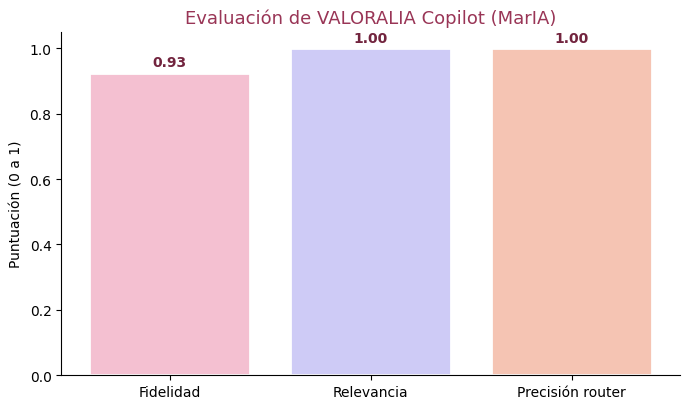

In [ ]:
import matplotlib.pyplot as plt

metricas = ["Fidelidad", "Relevancia", "Precisión router"]
valores = [media_fid, media_rel, precision_router]
colores = ["#F4C0D1", "#CECBF6", "#F5C4B3"]  # rosa, lila, melocotón pastel

fig, ax = plt.subplots(figsize=(7, 4.2))
barras = ax.bar(metricas, valores, color=colores, edgecolor="white", linewidth=2)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Puntuación (0 a 1)")
ax.set_title("Evaluación de VALORALIA Copilot (MarIA)", fontsize=13, color="#993556")
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold", color="#72243E")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# **14. Conclusiones y conexión con el TFM**

Llegados aquí, recapitulo qué he construido y por qué encaja en mi trabajo.

He montado VALORALIA Copilot, una asistente conversacional llamada MarIA que combina los tres módulos de la asignatura: usa un LLM como cerebro (módulo 2), un RAG sobre documentación verificada para no alucinar en temas delicados (módulo 3), y un agente con herramientas y un router que decide cuándo tasar, cuándo comparar y cuándo consultar la documentación (módulo 4). Y, lo más importante, no me he quedado en "funciona": lo he evaluado con RAGAS y con un evaluador propio de LLM-as-a-judge, midiendo fidelidad, relevancia y precisión del router.

La conexión con mi TFM es directa y por eso esta práctica me sirve dos veces. En el TFM construí el motor que predice precios; aquí construyo la capa que conversa, razona y decide cuándo usar ese motor. Mi modelo deja de ser el centro y se convierte en una herramienta que la asistente invoca. Esto es exactamente el siguiente paso natural en la hoja de ruta del producto: pasar de un motor de tasación a un producto conversacional que cualquiera puede usar. Lo incorporaré al TFM como un capítulo de capa de interacción.

Limitaciones, que ser honesta siempre suma: la base de conocimiento de la demo es de ejemplo y en producción deben ser los documentos verificados y fechados del cliente; el cálculo del precio usa el modelo real si está cargado y, si no, un fallback orientativo; y la evaluación se ha hecho sobre un conjunto pequeño, suficiente para una prueba de concepto pero ampliable.

Líneas futuras: cargar el modelo real en la herramienta, ampliar la documentación, añadir memoria de conversación para que MarIA recuerde el contexto entre turnos, y desplegarla con una interfaz web junto al despliegue que ya tengo de VALORALIA.

Y con esto cierro. Si el tribunal pregunta cómo sé que no alucina, saco la tabla de fidelidad. Si preguntan por qué reutilizo el TFM, respondo que no lo reutilizo: lo extiendo, convirtiéndolo en una herramienta de un sistema generativo distinto. Café, repaso y a por la matrícula.